In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models, applications
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import kagglehub
import os
import numpy as np
import time
from time import perf_counter

### Definition of input and output data
**Input (X)**  

Posterior and anterior chest X-ray images ( 5,863 X-Ray images in .jpeg format). The images will be resized to 224x224 to decrease the training time and will be converted to grayscale.  

**Output (Y)**

binary, patient is  
0 - healthy  
1 - has pneumonia

### Data localisation


Dataset: [Chest X-Ray Pneumonia (Kaggle)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)  
Citation: Kermany, Daniel S. et al. Cell, Volume 172, Issue 5, 1122 - 1131.e9  
Path: `/kaggle/input/chest-xray-pneumonia/chest_xray/train`, `val/`, `test/`


In [2]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
#paths to the data
base_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"

#create a training dataset with an 80/20 split for train/validation image_dataset_from_directory will infer labels from subfolder names.
train = image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="binary",
    seed=123,
    validation_split=0.2,
    subset="training",
    image_size=(224,224),
    batch_size=32
).map(lambda x,y: (preprocess_input(x), y))\
 .shuffle(1000)\
 .repeat()                      #make train infinite so steps_per_epoch works

val = image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="binary",
    seed=123,
    validation_split=0.2,
    subset="validation",
    image_size=(224,224),
    batch_size=32
).map(lambda x,y: (preprocess_input(x), y))

#load test set w/o split
test = image_dataset_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/test",
    labels="inferred",
    label_mode="binary",
    image_size=(224,224),
    batch_size=32
).map(lambda x,y: (preprocess_input(x), y))

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Data visualisation

Found 5216 files belonging to 2 classes.


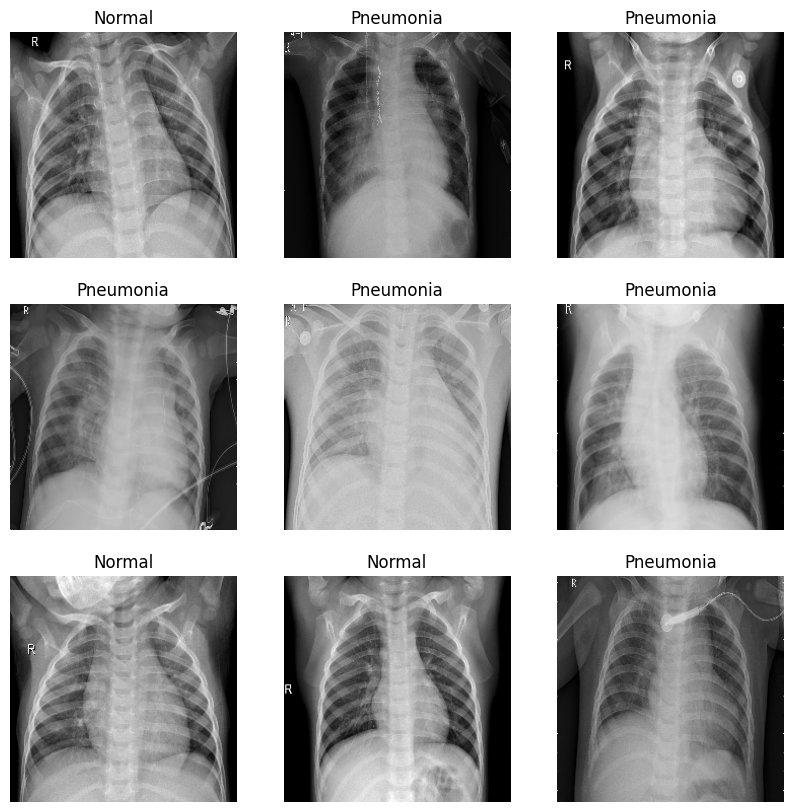

In [4]:
raw_train = image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    batch_size=9,
    image_size=(224,224),
    shuffle=True
)

for images, labels in  raw_train.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        plt.title("Pneumonia" if labels[i].numpy() == 1 else "Normal")
        plt.axis("off")


Histograms with class counts in three datasets:

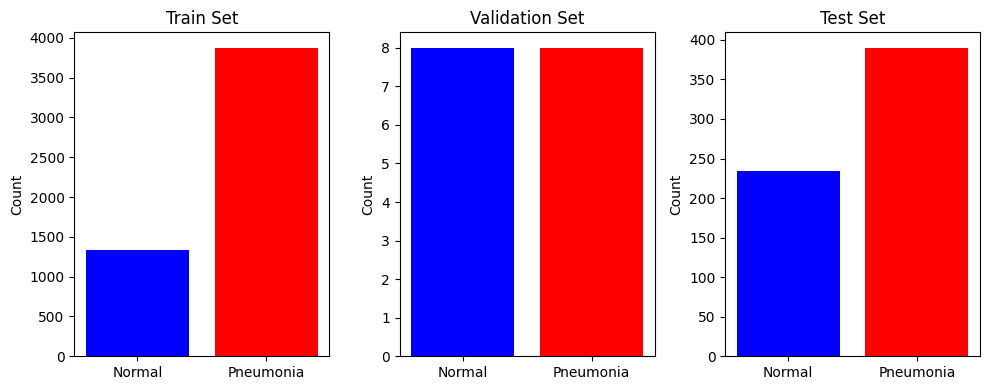

In [5]:
def count_labels_in_dir(directory):
    normal_count = len (os.listdir(os.path.join(directory, "NORMAL")))
    pneumonia_count = len(os.listdir(os.path.join(directory, "PNEUMONIA")))
    return normal_count, pneumonia_count

train_normal, train_pneumonia = count_labels_in_dir("/kaggle/input/chest-xray-pneumonia/chest_xray/train")
val_normal, val_pneumonia = count_labels_in_dir("/kaggle/input/chest-xray-pneumonia/chest_xray/val")
test_normal, test_pneumonia = count_labels_in_dir("/kaggle/input/chest-xray-pneumonia/chest_xray/test")

labels = ['Normal', 'Pneumonia']
x = range(len(labels))

fig, axis = plt.subplots(1,3, figsize=(10, 4))

axis[0].bar(x, [train_normal, train_pneumonia],color=['blue', 'red'])
axis[0].set_xticks(x)
axis[0].set_title("Train Set")
axis[0].set_xticklabels(labels)
axis[0].set_ylabel("Count")

axis[1].bar(x, [val_normal, val_pneumonia],color=['blue', 'red'])
axis[1].set_xticks(x)
axis[1].set_title("Validation Set")
axis[1].set_xticklabels(labels)
axis[1].set_ylabel("Count")


axis[2].bar(x, [test_normal, test_pneumonia],color=['blue', 'red'])
axis[2].set_xticks(x)
axis[2].set_title("Test Set")
axis[2].set_xticklabels(labels)
axis[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


Speed of data reading doesn't make sense since the dataset is infinite.

In [ ]:
%%time

def reading_benchmark(dataset):
  t1_start = perf_counter()
  for sample in dataset:
    time.sleep(1E-10)
  t1_stop = perf_counter()
  elapsed = t1_stop - t1_start
  return elapsed

elapsed_time_train=reading_benchmark(train)
elapsed_time_val=reading_benchmark(val)
elapsed_time_test=reading_benchmark(test)

print(f"Data loading time for training set: {elapsed_time_train:.2f} seconds")
print(f"Data loading time for validation set: {elapsed_time_val:.2f} seconds")
print(f"Data loading time for test set: {elapsed_time_test:.2f} seconds")

KeyboardInterrupt: 

In [7]:
#calculate class‐weights from folder counts
train_normal = len(os.listdir(os.path.join(base_dir, "NORMAL")))
train_pneum  = len(os.listdir(os.path.join(base_dir, "PNEUMONIA")))
total = train_normal + train_pneum
class_weights = {
    0: (total / (2 * train_normal)),
    1: (total / (2 * train_pneum))
}

#create EfficientNetB0 model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = applications.EfficientNetB0(
    include_top=False,
    input_shape=(224,224,3),
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

#compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC', 'Precision', 'Recall']
)

batch_size = 32
steps_per_epoch = (train_normal + train_pneum) // batch_size
#train
history = model.fit(
    train,
    validation_data=val,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    class_weight=class_weights,
    callbacks=[
      tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

#evaluate on test set:
test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(test, verbose=1)
print(f"Test  accuracy={test_acc:.3f}  AUC={test_auc:.3f}  precision={test_prec:.3f}  recall={test_rec:.3f}")


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - AUC: 0.7470 - Precision: 0.8535 - Recall: 0.7126 - accuracy: 0.6984 - loss: 0.5975 - val_AUC: 0.9704 - val_Precision: 0.9938 - val_Recall: 0.7901 - val_accuracy: 0.8332 - val_loss: 0.3627
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - AUC: 0.9402 - Precision: 0.9551 - Recall: 0.8544 - accuracy: 0.8640 - loss: 0.3216 - val_AUC: 0.9777 - val_Precision: 0.9928 - val_Recall: 0.8543 - val_accuracy: 0.8821 - val_loss: 0.2677
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - AUC: 0.9530 - Precision: 0.9635 - Recall: 0.8631 - accuracy: 0.8765 - loss: 0.2797 - val_AUC: 0.9806 - val_Precision: 0.9929 - val_Recall: 0.8580 - val_accuracy: 0.8849 - val_loss: 0.2595
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - AUC: 0.9624 - Precision: 0.9716 - Recall: 0.8881 - accuracy: 0.8977 - loss: 0.2444 - val_AUC: 0.9838 - val_Precision: 0.9943 - val_Recall: 0.8679 - val_accuracy: 0.8936 - val_loss: 0.2394
Epoch 5/20
163/163 ━

### Training & Validation Curves

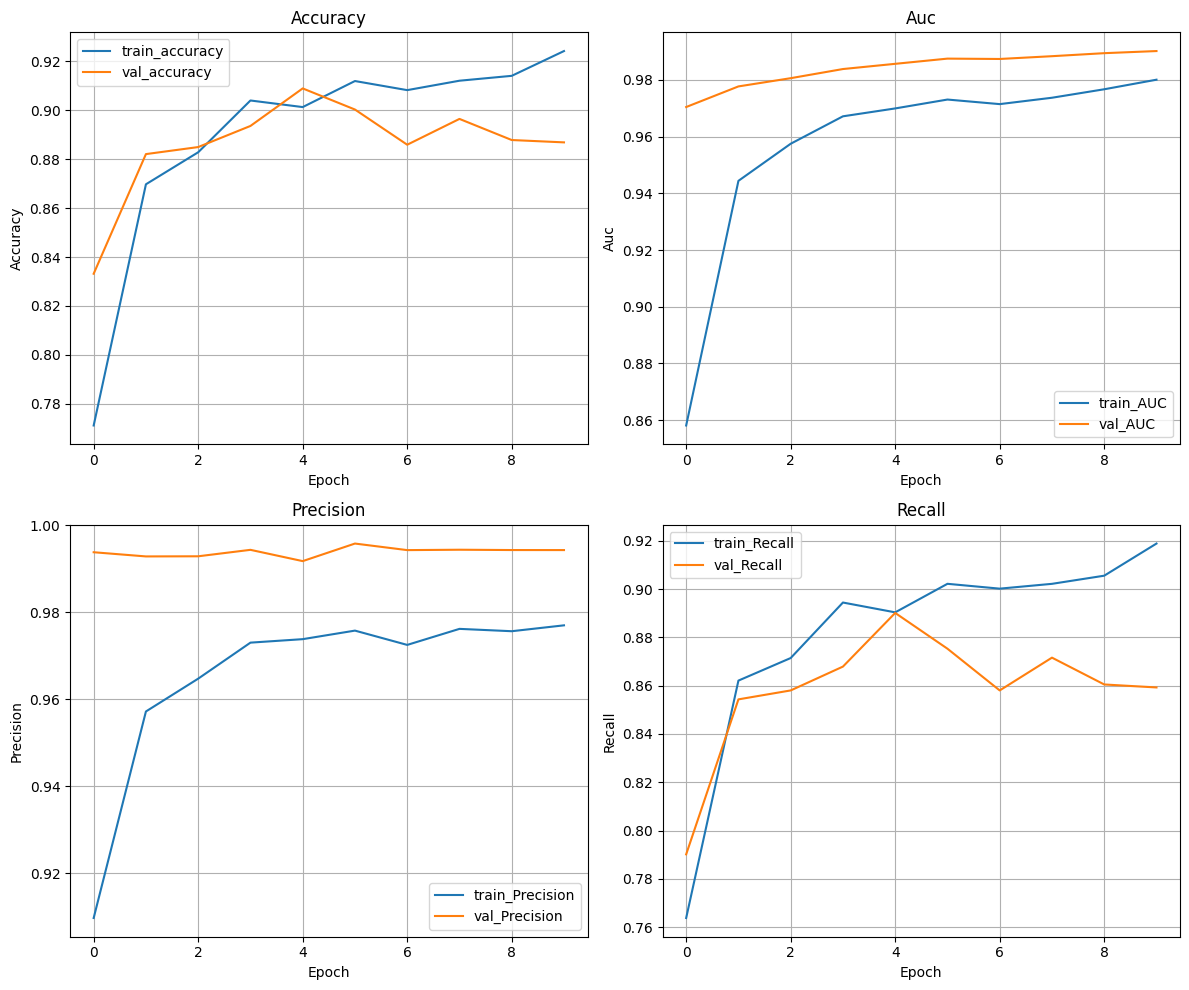

In [8]:
def plot_train_metrics(history, log_scale):

    metrics = ['accuracy', 'AUC', 'Precision', 'Recall']
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, met in enumerate(metrics):
        ax = axes[idx]
        ax.plot(history.history[met],      label=f'train_{met}')
        ax.plot(history.history[f'val_{met}'], label=f'val_{met}')
        ax.set_title(met.replace('_', ' ').title())
        ax.set_xlabel('Epoch')
        ax.set_ylabel(met.replace('_', ' ').title())
        ax.legend()
        ax.grid(True)
        if log_scale:
          ax.set_yscale('log')

    plt.tight_layout()
    plt.show()
# after your model.fit(...)
plot_train_metrics(history, False)


Test  accuracy=0.843  AUC=0.924  precision=0.841  recall=0.923

1. Accuracy

   - Both train (0.77 -> 0.92) and val (0.84->0.88) accuracy increase quickly over the first 5 epochs, indicating the head and backbone are learning distinguishing features.
   - After epoch 2, val accuracy fluctuates around 0.90.

2. AUC

   * The area-under-curve metric is good for val dataset (stays around 0.985). AUC starts at 0.86 for training dataset and reaches 0.98 by epoch 10.
   * AUC remains the same for both sets, which shows that the model has a reliable ability to score positives higher than negatives.

3. Precision

   * Validation precision is nearly perfect (> 0.995) from the beginning. This means when the model calls a case “pneumonia,” it’s almost always correct.
   * Training precision has a lower value at the beggining (around 0.91) but increases up to 0.97 by the end of training.

4. Recall

   * Training recall rises to ~0.92 by epoch 10.
   * Validation recall goes up to 0.89 but then drops down to 0.86.

To summarise:

* Fast model convergence.
* Presence of overfitting since val accuracy & recall peak around epoch 4–5 then drift down slightly by epoch 9
* The model learns quickly and has high AUC > 0.98 from the start of the training.
* Precision remains very high on both sets => false positives are rare => nearly all pneumonia cases are classified correctly.

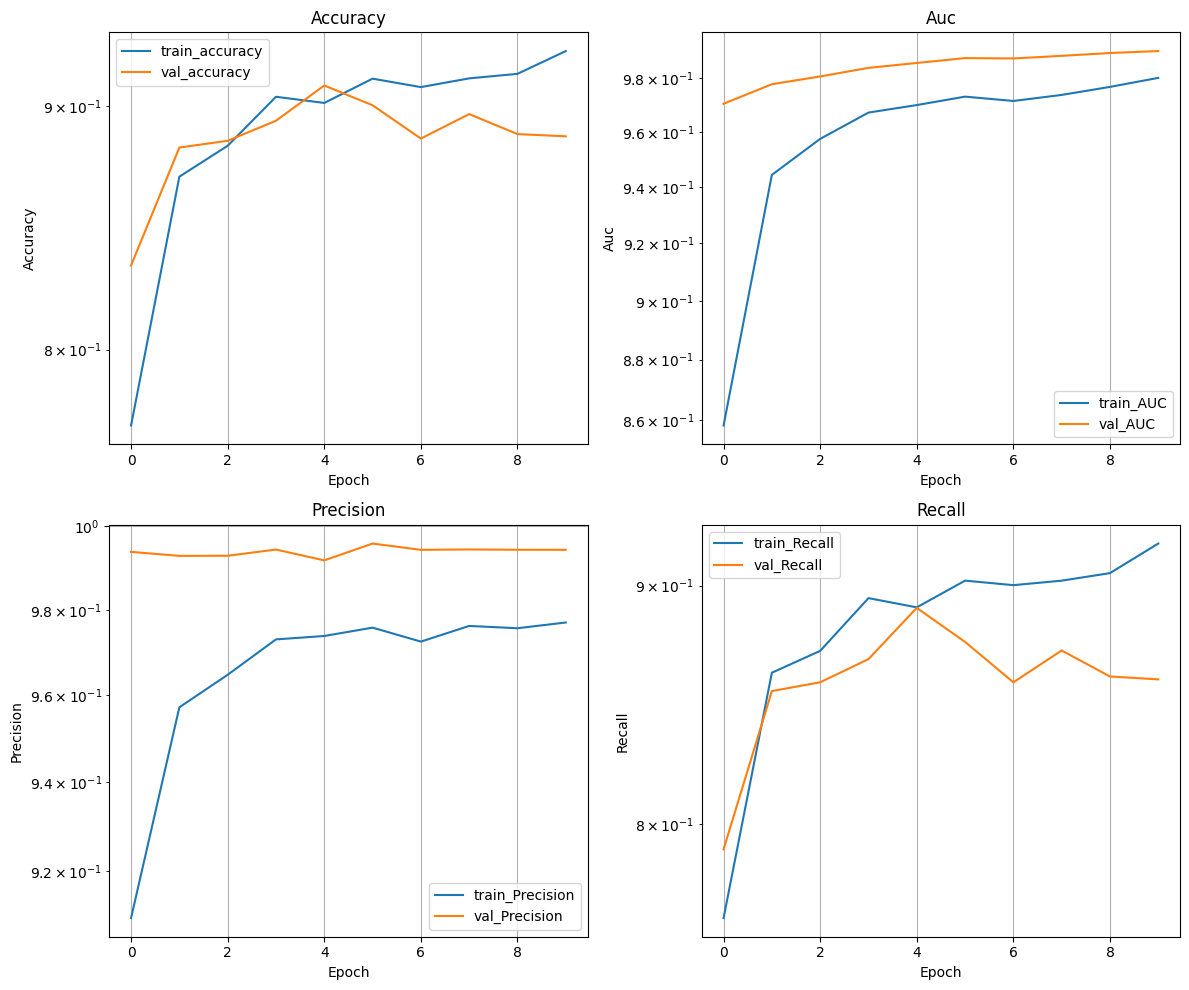

In [9]:
plot_train_metrics(history, True)

In my original project proposal I planned to train a small CNN from scratch (three conv-pool blocks → 128-unit dense → sigmoid). But when I started to test my model it was not enoug and prone to over-fitting (validation accuracy stuck at 50 % and never went above that).

In my original submission I also did the data loading differently and I think it also contributed to the problem of model being stuck at 50% accuraccy.

 My validation set was a subset of my training files (so the model never really saw new examples), I was casting grayscale floats to uint8 for visualization (which hid whether my pipeline was working), and I also needed to use preprocessing that EfficientNet expects.

With different data loading my train/val/test splits are disjoint and prevented my training from stucking at 50% accuracy.


### Confusion Matrices

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


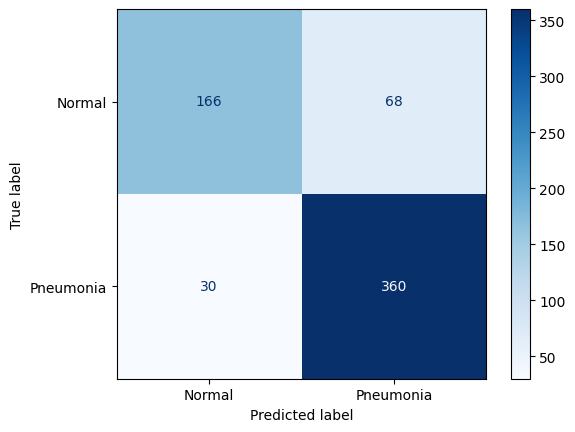

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test:
    probs = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((probs > 0.5).astype("int32"))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap='Blues')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


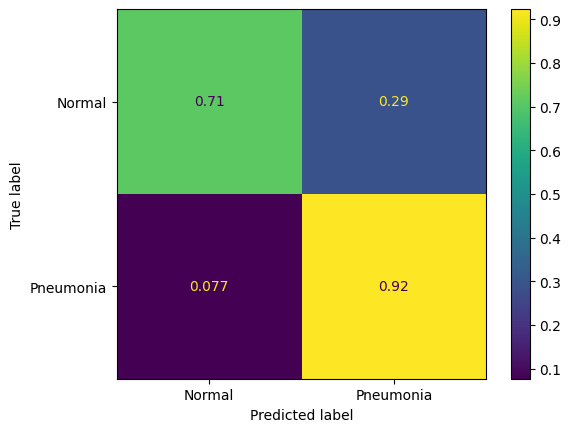

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test:
    probs = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((probs > 0.5).astype("int32"))

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Normal", "Pneumonia"])
disp.plot()


* True Normal → Predicted Normal: 0.71
* True Normal → Predicted Pneumonia: 0.29
* True Pneumonia → Predicted Normal: 0.077
* True Pneumonia → Predicted Pneumonia: 0.92

Interpretation:

* Sensitivity (Recall) for Pneumonia is 92%, which means that the model is very good at identifying true pneumonia cases.
* Specificity for Normal is 71%, so about 29% of healthy X-rays are classified as pneumonia.

For a medical test missing a pneumonia is much worse than over-diagnosing it, this high sensitivity combined with moderate specificity can be acceptable.
